# Hydrate mitigation choices: methanol, MEG, and AA-LDHI

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/flowassurance/hydrate_mitigation_chemical_choice_4016.ipynb) · [Examples catalog](../examples_of_NeqSim_in_Colab.ipynb)

**Purpose.** Use NeqSim to screen thermodynamic hydrate inhibition for a synthetic wet gas–condensate mixture, then show why an anti-agglomerant (AA-LDHI) requires a *different* qualification route. The comparison is motivated by [NeqSim issue #4016](https://github.com/equinor/neqsim/issues/4016) and [Baraka-Lokmane, OTC Asia 2026](https://www.semanticscholar.org/paper/2d7aae387df718d82f3d027f6d70f818c89fd13d).

The accessible paper abstract describes three analog formation waters (15–25 g/L total dissolved solids), scale and corrosion interactions, and an AA-LDHI preference in its particular study. **Its field composition, detailed measurements, inhibitor recipes and scale model are not reproduced here.** Every numerical input below is synthetic and the outputs are NeqSim calculations, not paper data or a field recommendation.

**Learning objectives:** (1) specify inhibitor mass fractions correctly; (2) compare hydrate boundaries and flowline margins; (3) recognize the difference between thermodynamic inhibition and particle dispersion; (4) inspect a separate, limited aqueous scale screen; (5) identify experiments required to choose an inhibitor.

## 1. Run in a fresh Colab runtime

Run **Runtime → Run all**. The first code cell installs the Python bridge. The next fetches the exact NeqSim master revision used for these saved results, builds the Java JAR and verifies the loaded class origin. A JDK is required (Colab supplies one). Set `NEQSIM_SOURCE_REF=master` only when deliberately testing newer source; then rerun from a fresh runtime. Local maintainers may set `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` to a clean, matching source checkout and build.

All pressures are **bara**, temperatures **°C**, inhibitor percentages **mass percent of water plus inhibitor at the injection point**, and the component amounts are a finite molar inventory. They do not imply a rate or guarantee the same aqueous concentration at every location: partitioning, losses, mixing, and produced-water variability require separate evaluation.

In [1]:
%pip -q install neqsim==3.20.0 JPype1==1.7.1 numpy pandas matplotlib nbformat
print("Python dependencies installed.")

Note: you may need to restart the kernel to use updated packages.
Python dependencies installed.


In [2]:
import hashlib
import importlib.metadata
import json
import os
import platform
import subprocess
from pathlib import Path
from urllib.parse import unquote, urlparse

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NEQSIM_SOURCE_REF = os.environ.get(
    "NEQSIM_SOURCE_REF", "bbdd569337e88591bab324960fb016fb2fae7ea0"
)
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-hydrate-source")).resolve()
source_jar_setting = os.environ.get("NEQSIM_SOURCE_JAR")


def run_checked(arguments, working_directory=None):
    result = subprocess.run(
        arguments, cwd=working_directory, text=True, capture_output=True, check=True
    )
    return result.stdout.strip()


if source_jar_setting is None:
    if not source_root.exists():
        run_checked(["git", "init", str(source_root)])
        run_checked(
            ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
            source_root,
        )
    run_checked(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF], source_root)
    run_checked(["git", "checkout", "--detach", "FETCH_HEAD"], source_root)
    run_checked(
        [
            "bash", "mvnw", "-B", "-Dmaven.test.skip=true", "-Dmaven.javadoc.skip=true",
            "-Dspotless.skip=true", "package",
        ],
        source_root,
    )
    candidates = [
        candidate for candidate in (source_root / "target").glob("neqsim-*.jar")
        if not any(marker in candidate.name for marker in ("shaded", "sources", "javadoc"))
    ]
    assert len(candidates) == 1, candidates
    source_jar = candidates[0].resolve()
else:
    source_jar = Path(source_jar_setting).resolve()

source_commit = run_checked(["git", "rev-parse", "HEAD"], source_root)
if len(NEQSIM_SOURCE_REF) == 40:
    assert source_commit == NEQSIM_SOURCE_REF, (source_commit, NEQSIM_SOURCE_REF)
assert not run_checked(["git", "status", "--porcelain", "--untracked-files=no"], source_root)
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
assert not jpype.isJVMStarted(), "Restart the runtime before changing the Java library."
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xmx2g", "-Xrs", "-Djava.awt.headless=true", convertStrings=True)
from neqsim import jneqsim

FluidClass = jneqsim.thermo.system.SystemSrkCPAstatoil
Operations = jneqsim.thermodynamicoperations.ThermodynamicOperations
ScaleCalculator = jneqsim.pvtsimulation.flowassurance.ScalePredictionCalculator
class_url = str(FluidClass.class_.getProtectionDomain().getCodeSource().getLocation())
loaded_path = Path(unquote(urlparse(class_url).path)).resolve()
assert loaded_path == source_jar, (loaded_path, source_jar)

provenance = {
    "source_commit": source_commit,
    "jar_sha256": jar_sha256,
    "loaded_from_source_jar": loaded_path == source_jar,
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python": platform.python_version(),
    "neqsim_bridge": importlib.metadata.version("neqsim"),
}
print(json.dumps(provenance, indent=2))
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

{
  "source_commit": "bbdd569337e88591bab324960fb016fb2fae7ea0",
  "jar_sha256": "cb97ce9fce0a6df5eb7ce1958b39190e162692b0dc6dce6f3b5622a93a50d1eb",
  "loaded_from_source_jar": true,
  "java": "17.0.20",
  "python": "3.12.14",
  "neqsim_bridge": "3.20.0"
}


## 2. Synthetic inventory and thermodynamic model

Use SRK-CPA with mixing rule 10 and a water-rich phase. The guest mixture contains methane, ethane and propane; a small C6/C10 tail gives a separate oil phase at the boundary. Fix 1 kg water and add each thermodynamic inhibitor on a water-plus-inhibitor mass basis:

$$m_I=m_w\frac{w_I}{1-w_I},\qquad n_I=\frac{m_I}{M_I}$$

Here $m_I$ and $m_w$ are kg, $w_I$ is the specified mass fraction, $M_I$ is kg/mol and $n_I$ is mol. The feed ratio is an **input**; it is not an asserted aqueous outlet concentration. Hydrate equilibrium means equal water fugacity in hydrate and aqueous phases. NeqSim's hydrate temperature is an incipient equilibrium boundary, not a hydrate mass, formation time, plug probability or AA performance prediction.

In [3]:
WATER_KG = 1.0
MOLAR_MASS_KG_MOL = {"water": 0.01801528, "methanol": 0.03204186, "MEG": 0.06206784}
GAS_CONDENSATE_MOLES = {
    "methane": 10.0,
    "ethane": 0.4,
    "propane": 0.1,
    "n-hexane": 0.04,
    "n-decane": 0.01,
}
PRESSURES_BARA = [60.0, 80.0, 100.0]
RECIPES = [(None, 0.0)] + [
    (inhibitor, weight_fraction)
    for inhibitor in ("methanol", "MEG")
    for weight_fraction in (0.1, 0.2, 0.3, 0.4)
]


def make_fluid(pressure_bara, inhibitor=None, weight_fraction=0.0):
    if not 0.0 <= weight_fraction < 1.0:
        raise ValueError("Inhibitor fraction must lie in [0, 1).")
    if inhibitor not in (None, "methanol", "MEG"):
        raise ValueError("Use an explicit thermodynamic inhibitor, not an AA proxy.")
    model = FluidClass(283.15, float(pressure_bara))
    for component, amount_mol in GAS_CONDENSATE_MOLES.items():
        model.addComponent(component, amount_mol)
    model.addComponent("water", WATER_KG / MOLAR_MASS_KG_MOL["water"])
    if inhibitor is not None and weight_fraction > 0.0:
        inhibitor_kg = WATER_KG * weight_fraction / (1.0 - weight_fraction)
        model.addComponent(inhibitor, inhibitor_kg / MOLAR_MASS_KG_MOL[inhibitor])
    model.setMixingRule(10)
    model.setMultiPhaseCheck(True)
    model.setHydrateCheck(True)
    return model


def hydrate_point(pressure_bara, inhibitor=None, weight_fraction=0.0):
    model = make_fluid(pressure_bara, inhibitor, weight_fraction)
    Operations(model).hydrateFormationTemperature()
    labels = [str(model.getPhase(index).getType()) for index in range(model.getNumberOfPhases())]
    if "AQUEOUS" not in labels or "GAS" not in labels:
        raise AssertionError(f"Missing aqueous or guest-rich phase: {labels}")
    aqueous = model.getPhase("aqueous")
    hydrate = model.getPhase(4)
    residual = 1.0 - hydrate.getFugacity("water") / aqueous.getFugacity("water")
    phases = [model.getPhase(index) for index in range(model.getNumberOfPhases())]
    balance_errors = []
    for index in range(model.getPhase(0).getNumberOfComponents()):
        recovered = sum(
            phase.getBeta() * phase.getComponent(index).getx() for phase in phases
        )
        overall = model.getPhase(0).getComponent(index).getz()
        balance_errors.append(abs(recovered - overall))
    result = {
        "inhibitor": inhibitor or "None",
        "feed_inhibitor_wt_percent": weight_fraction * 100.0,
        "pressure_bara": pressure_bara,
        "hydrate_temperature_c": float(model.getTemperature("C")),
        "phases": "+".join(labels),
        "hydrate_fugacity_residual": float(residual),
        "max_component_fraction_error": max(balance_errors),
        "phase_fraction_error": abs(sum(phase.getBeta() for phase in phases) - 1.0),
    }
    return result, model


single_result, single_model = hydrate_point(80.0)
display(pd.DataFrame([single_result]).T.rename(columns={0: "Uninhibited at 80 bara"}))

,Uninhibited at 80 bara
inhibitor,None
feed_inhibitor_wt_percent,0.0
pressure_bara,80.0
hydrate_temperature_c,15.883195
phases,GAS+OIL+AQUEOUS
hydrate_fugacity_residual,0.0
max_component_fraction_error,0.0
phase_fraction_error,0.0


## 3. Compare methanol and MEG at three pressures

Each point is solved on a fresh fluid with the *same* gas–condensate and water inventories. Changing inhibitor mass changes the total system inventory. Curves must be interpreted at their explicit injection recipe, not as equal delivered chemical rates. Numerical acceptance checks reject a result with inconsistent fugacity or material balance.

In [4]:
records = []
for pressure_bara in PRESSURES_BARA:
    for inhibitor, weight_fraction in RECIPES:
        record, _ = hydrate_point(pressure_bara, inhibitor, weight_fraction)
        records.append(record)

results = pd.DataFrame(records)
assert results["hydrate_temperature_c"].between(-40.0, 35.0).all()
assert results["hydrate_fugacity_residual"].abs().max() < 2.0e-6
assert results["max_component_fraction_error"].max() < 1.0e-8
assert results["phase_fraction_error"].max() < 1.0e-9
assert results["phases"].str.contains("OIL").all()

for inhibitor in ("methanol", "MEG"):
    group = results[results["inhibitor"] == inhibitor]
    for _, pressure_group in group.groupby("pressure_bara"):
        ordered = pressure_group.sort_values("feed_inhibitor_wt_percent")
        assert np.all(np.diff(ordered["hydrate_temperature_c"]) < 0.0)

summary = results.pivot_table(
    index=["inhibitor", "feed_inhibitor_wt_percent"],
    columns="pressure_bara",
    values="hydrate_temperature_c",
)
summary.columns = [f"{pressure:.0f} bara: hydrate °C" for pressure in summary.columns]
display(summary.round(2))
print("Maximum hydrate residual:", results["hydrate_fugacity_residual"].abs().max())
print("Maximum component balance error:", results["max_component_fraction_error"].max())

Maximum hydrate residual: 7.127825091268747e-07
Maximum component balance error: 5.773159728050814e-15


60 bara: hydrate °C  ...  100 bara: hydrate °C
inhibitor feed_inhibitor_wt_percent                       ...                      
MEG       10.0                                     11.64  ...                 14.85
          20.0                                      8.57  ...                 11.69
          30.0                                      4.65  ...                  7.65
          40.0                                     -0.29  ...                  2.55
None      0.0                                      13.95  ...                 17.22
methanol  10.0                                      9.78  ...                 12.93
          20.0                                      4.85  ...                  7.84
          30.0                                     -0.87  ...                  1.94
          40.0                                     -7.45  ...                 -4.85

[9 rows x 3 columns]

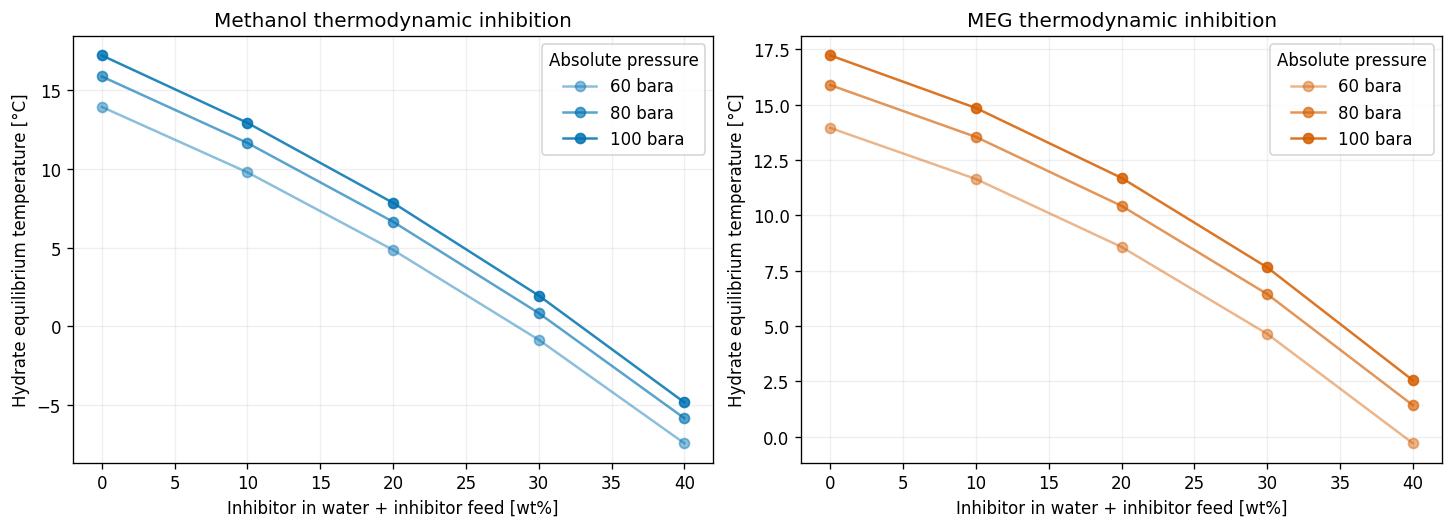

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
for pressure_bara in PRESSURES_BARA:
    pressure_results = results[results["pressure_bara"] == pressure_bara]
    baseline = pressure_results.loc[pressure_results["inhibitor"] == "None"]
    baseline_temperature = baseline["hydrate_temperature_c"].iloc[0]
    for axis, inhibitor, color in zip(
        axes, ("methanol", "MEG"), ("#0072B2", "#D55E00")
    ):
        subset = pressure_results[pressure_results["inhibitor"] == inhibitor]
        axis.plot(
            [0.0] + subset["feed_inhibitor_wt_percent"].tolist(),
            [baseline_temperature] + subset["hydrate_temperature_c"].tolist(),
            marker="o", label=f"{pressure_bara:.0f} bara", color=color,
            alpha=0.45 + (pressure_bara - 60.0) / 100.0,
        )
        axis.set(
            title=f"{inhibitor.upper() if inhibitor == 'MEG' else 'Methanol'} thermodynamic inhibition",
            xlabel="Inhibitor in water + inhibitor feed [wt%]",
            ylabel="Hydrate equilibrium temperature [°C]",
        )
        axis.legend(title="Absolute pressure")
plt.show()

## 4. Compare an illustrative flowline condition

The operating margin is $M=T_{op}-T_h$. Positive margin means the fluid is above the calculated incipient boundary; a negative value is hydrate-favorable when free water and gas are present. The illustrative screen asks for $M\geq3$ K at every station. It is an educational allowance, not a project criterion.

**AA-LDHI is deliberately absent from the equilibrium-dose table:** an anti-agglomerant can permit hydrate particles to form while reducing their tendency to form a plug. Setting its concentration as an apparent equilibrium temperature reduction would assert a mechanism this model does not compute. The uninhibited subcooling is useful as *one input* to a separate AA experimental qualification.

In [6]:
station_inputs = pd.DataFrame({
    "station": ["Wellhead", "Cold flowline", "Arrival"],
    "pressure_bara": [100.0, 80.0, 60.0],
    "operating_temperature_c": [14.0, 7.0, 4.0],
})
station_rows = []
for inhibitor, fraction in RECIPES:
    for _, station in station_inputs.iterrows():
        entry = results.loc[
            (results["pressure_bara"] == station["pressure_bara"])
            & (results["inhibitor"] == (inhibitor or "None"))
            & (results["feed_inhibitor_wt_percent"] == fraction * 100.0)
        ].iloc[0]
        station_rows.append({
            "inhibitor": inhibitor or "None",
            "feed_wt_percent": fraction * 100.0,
            "station": station["station"],
            "pressure_bara": station["pressure_bara"],
            "operating_temperature_c": station["operating_temperature_c"],
            "hydrate_temperature_c": entry["hydrate_temperature_c"],
            "margin_k": station["operating_temperature_c"] - entry["hydrate_temperature_c"],
        })

margins = pd.DataFrame(station_rows)
display(margins.round(2))
worst_margin = margins.groupby(["inhibitor", "feed_wt_percent"])["margin_k"].min()
display(worst_margin.rename("minimum_station_margin_k").round(2).to_frame())
print("Cases satisfying illustrative 3 K allowance:")
display(worst_margin[worst_margin >= 3.0].rename("minimum_margin_k").to_frame())

Cases satisfying illustrative 3 K allowance:


,inhibitor,feed_wt_percent,station,pressure_bara,operating_temperature_c,hydrate_temperature_c,margin_k
0,None,0.0,Wellhead,100.0,14.0,17.22,-3.22
1,None,0.0,Cold flowline,80.0,7.0,15.88,-8.88
2,None,0.0,Arrival,60.0,4.0,13.95,-9.95
3,methanol,10.0,Wellhead,100.0,14.0,12.93,1.07
4,methanol,10.0,Cold flowline,80.0,7.0,11.65,-4.65
5,methanol,10.0,Arrival,60.0,4.0,9.78,-5.78
6,methanol,20.0,Wellhead,100.0,14.0,7.84,6.16
7,methanol,20.0,Cold flowline,80.0,7.0,6.64,0.36
8,methanol,20.0,Arrival,60.0,4.0,4.85,-0.85
9,methanol,30.0,Wellhead,100.0,14.0,1.94,12.06


minimum_station_margin_k
inhibitor feed_wt_percent                          
MEG       10.0                                -7.64
          20.0                                -4.57
          30.0                                -0.65
          40.0                                 4.29
None      0.0                                 -9.95
methanol  10.0                                -5.78
          20.0                                -0.85
          30.0                                 4.87
          40.0                                11.45

minimum_margin_k
inhibitor feed_wt_percent                  
MEG       40.0                     4.294753
methanol  30.0                     4.872018
          40.0                    11.454746

In [7]:
base_curve = margins[margins["inhibitor"] == "None"].copy()
base_curve["unmitigated_subcooling_k"] = (
    base_curve["hydrate_temperature_c"] - base_curve["operating_temperature_c"]
).clip(lower=0.0)
display(base_curve[[
    "station", "pressure_bara", "operating_temperature_c",
    "hydrate_temperature_c", "unmitigated_subcooling_k",
]].round(2))
print("AA-LDHI qualification: no model result for dispersion, dose, plugging or scale effect.")

AA-LDHI qualification: no model result for dispersion, dose, plugging or scale effect.


,station,pressure_bara,operating_temperature_c,hydrate_temperature_c,unmitigated_subcooling_k
0,Wellhead,100.0,14.0,17.22,3.22
1,Cold flowline,80.0,7.0,15.88,8.88
2,Arrival,60.0,4.0,13.95,9.95


## 5. Separate aqueous scale screening for synthetic analog waters

The paper's **accessible abstract** reports that inhibitor and MDEA choices changed scale risk in its specific waters. NeqSim's `ScalePredictionCalculator` provides a water-chemistry screen using concentration, pH and a Davies activity approximation. It **does not accept methanol, MEG, AA-LDHI or MDEA as mixed-solvent inputs**, so its results below cannot rank the actual inhibitor options. The pH 9.2 row is a **prescribed sensitivity** motivated by the abstract's reported MDEA case; it is not a calculation of MDEA dosing or pH.

These three ionic recipes are invented teaching data, only their total dissolved solids span 15–25 g/L as in the abstract. They are not field samples, a matched brine chemistry, or paper validation data. Values of $SI=\log_{10}(IAP/K_{sp})$ above zero indicate a thermodynamic tendency in this screening model, with $IAP$ and $K_{sp}$ both in the same activity convention. No precipitation rate, deposition, inhibitor compatibility or oil/water transport is calculated. Independent laboratory and more complete mixed-solvent electrolyte checks are needed before using these screens for design.

In [8]:
WATERS = [
    {"name": "Synthetic A", "tds_mg_l": 15000.0, "ca_mg_l": 350.0,
     "sr_mg_l": 20.0, "so4_mg_l": 180.0, "hco3_mg_l": 350.0},
    {"name": "Synthetic B", "tds_mg_l": 20000.0, "ca_mg_l": 650.0,
     "sr_mg_l": 45.0, "so4_mg_l": 300.0, "hco3_mg_l": 400.0},
    {"name": "Synthetic C", "tds_mg_l": 25000.0, "ca_mg_l": 950.0,
     "sr_mg_l": 70.0, "so4_mg_l": 450.0, "hco3_mg_l": 450.0},
]
scale_rows = []
for water in WATERS:
    for prescribed_ph in (6.5, 9.2):
        calculator = ScaleCalculator()
        calculator.setTemperatureCelsius(35.0)
        calculator.setPressureBara(80.0)
        calculator.setTotalDissolvedSolids(water["tds_mg_l"])
        calculator.setCalciumConcentration(water["ca_mg_l"])
        calculator.setStrontiumConcentration(water["sr_mg_l"])
        calculator.setSulphateConcentration(water["so4_mg_l"])
        calculator.setBicarbonateConcentration(water["hco3_mg_l"])
        calculator.setSodiumConcentration(water["tds_mg_l"] * 0.35)
        calculator.setPH(prescribed_ph)
        calculator.calculate()
        scale_rows.append({
            "water": water["name"], "TDS_mg_l": water["tds_mg_l"],
            "prescribed_pH": prescribed_ph,
            "calcite_SI": calculator.getCaCO3SaturationIndex(),
            "anhydrite_SI": calculator.getCaSO4SaturationIndex(),
            "celestite_SI": calculator.getSrSO4SaturationIndex(),
        })
scale_screen = pd.DataFrame(scale_rows)
assert np.isfinite(scale_screen[[
    "calcite_SI", "anhydrite_SI", "celestite_SI"
]].to_numpy()).all()
display(scale_screen.round(2))
print("Scale model: aqueous pH sensitivity only; no mixed-solvent inhibitor ranking.")

Scale model: aqueous pH sensitivity only; no mixed-solvent inhibitor ranking.


,water,TDS_mg_l,prescribed_pH,calcite_SI,anhydrite_SI,celestite_SI
0,Synthetic A,15000.0,6.5,-0.74,-1.60,-1.45
1,Synthetic A,15000.0,9.2,1.95,-1.60,-1.45
2,Synthetic B,20000.0,6.5,-0.44,-1.12,-0.88
3,Synthetic B,20000.0,9.2,2.25,-1.12,-0.88
4,Synthetic C,25000.0,6.5,-0.24,-0.76,-0.49
5,Synthetic C,25000.0,9.2,2.46,-0.76,-0.49


## 6. Decision handoff and validation

| Option | NeqSim result demonstrated | Missing decision evidence |
|---|---|---|
| Methanol | CPA hydrate equilibrium versus injected mass fraction | Partitioning and delivered aqueous concentration, losses and recovery; scale in mixed solvent |
| MEG | CPA hydrate equilibrium versus injected mass fraction | Rich/lean loop, regeneration, salt buildup and mixed-solvent scale |
| AA-LDHI | Uninhibited hydrate subcooling as a lab-test condition | Product-specific flow-loop and shut-in/restart tests, water-cut and condensate effects, dose and compatibility |
| MDEA with any option | Prescribed-pH aqueous sensitivity only | Reactive mixed-solvent pH, carbonate/sulfate scale and corrosion validation |

The hydrate results passed fugacity and component checks, and the inhibition trends were checked at all three pressures. This validates *calculation consistency*, not model accuracy for the paper's field. For a real choice, obtain formation-water ion analyses and hydrocarbon PVT, measure hydrate boundaries for methanol/MEG, measure partitioning, run high-pressure AA dispersion/plugging tests across water cut and shutdown states, and benchmark multi-mineral scale against mixed-solvent experiments. See the tracked [issue #4016](https://github.com/equinor/neqsim/issues/4016) and the [electrolyte roadmap #3144](https://github.com/equinor/neqsim/issues/3144).

In [9]:
validation = {
    "hydrate_cases": len(results),
    "all_hydrate_cases_have_gas_oil_water": bool(results["phases"].str.contains("OIL").all()),
    "max_fugacity_residual": float(results["hydrate_fugacity_residual"].abs().max()),
    "max_component_fraction_error": float(results["max_component_fraction_error"].max()),
    "minimum_margin_k_by_recipe": {
        f"{inhibitor}, {fraction:.0f} wt%": round(float(margin), 2)
        for (inhibitor, fraction), margin in worst_margin.items()
    },
    "scale_scenarios": len(scale_screen),
    "scale_is_water_only_screen": True,
    "paper_numeric_reproduction": False,
    "AA_performance_predicted": False,
}
print(json.dumps(validation, indent=2))

{
  "hydrate_cases": 27,
  "all_hydrate_cases_have_gas_oil_water": true,
  "max_fugacity_residual": 7.127825091268747e-07,
  "max_component_fraction_error": 5.773159728050814e-15,
  "minimum_margin_k_by_recipe": {
    "MEG, 10 wt%": -7.64,
    "MEG, 20 wt%": -4.57,
    "MEG, 30 wt%": -0.65,
    "MEG, 40 wt%": 4.29,
    "None, 0 wt%": -9.95,
    "methanol, 10 wt%": -5.78,
    "methanol, 20 wt%": -0.85,
    "methanol, 30 wt%": 4.87,
    "methanol, 40 wt%": 11.45
  },
  "scale_scenarios": 6,
  "scale_is_water_only_screen": true,
  "paper_numeric_reproduction": false,
  "AA_performance_predicted": false
}


### Limitations and exercises

1. Change the gas composition and re-evaluate the pressure–temperature boundary and phase check.
2. Replace the synthetic brines with *public or authorized* measured ion analyses and a stated pH basis.
3. Add measured hydrate equilibrium points with uncertainties, then calculate residuals on a held-out set. Do not fit directly to the comparison set.
4. Define an AA-LDHI test matrix with subcooling, water cut, liquid loading, shear, duration and restart conditions. Keep its acceptance separate from hydrate equilibrium.

**Provenance.** Java source and bridge versions appear above. The paper connection is conceptual because a numerical dataset and full inhibitor recipes were not accessible. Existing NeqSim equilibrium and aqueous scale APIs were sufficient to teach the valid portions; a calibrated inhibitor-aware mixed-solvent mineral-scale workflow remains a separate library improvement.